In [ ]:
import librosa
import numpy as np
from spafe.features.cqcc import cqcc


In [ ]:
def extract_cqcc(
    wav_path,
    sr=16000,
    num_ceps=13,
    nfft=512,
    hop_length=160,
    win_len=0.025,
    fmin=20,
    fmax=None,
    bins_per_octave=96
):
    # Load audio
    signal, sr = librosa.load(wav_path, sr=sr)

    # CQCC
    cqcc_feat = cqcc(
        sig=signal,
        fs=sr,
        num_ceps=num_ceps,
        nfft=nfft,
        win_len=win_len,
        win_hop=hop_length / sr,
        fmin=fmin,
        fmax=fmax,
        bins_per_octave=bins_per_octave
    )

    # CMVN (rất quan trọng)
    cqcc_feat = (cqcc_feat - np.mean(cqcc_feat, axis=0)) / \
                (np.std(cqcc_feat, axis=0) + 1e-8)

    return cqcc_feat   # (num_frames, num_ceps)


In [56]:
import librosa
non_speech_mix, sr_1 = librosa.load("C:/Users/Vinh/Documents/Pythonfile/Voice-Activity-Detect/data/test/non_speech_mix.wav")
non_speech, sr_2 = librosa.load("C:/Users/Vinh/Documents/Pythonfile/Voice-Activity-Detect/data/test/non_speech.wav")
speech_mix, sr_3 = librosa.load('C:/Users/Vinh/Documents/Pythonfile/Voice-Activity-Detect/data/test/speech_mix.wav')
speech, sr_4 = librosa.load('C:/Users/Vinh/Documents/Pythonfile/Voice-Activity-Detect/data/test/speech_mix.wav')

In [59]:

n_sp_m_feature = cqcc_from_scratch_multiframe("C:/Users/Vinh/Documents/Pythonfile/Voice-Activity-Detect/data/test/non_speech_mix.wav")
n_sp_feature = cqcc_from_scratch_multiframe("C:/Users/Vinh/Documents/Pythonfile/Voice-Activity-Detect/data/test/non_speech.wav")
sp_m_feature = cqcc_from_scratch_multiframe('C:/Users/Vinh/Documents/Pythonfile/Voice-Activity-Detect/data/test/speech_mix.wav')
sp_feature = cqcc_from_scratch_multiframe('C:/Users/Vinh/Documents/Pythonfile/Voice-Activity-Detect/data/test/speech_mix.wav')
print(n_sp_m_feature.shape)

(6018, 13)


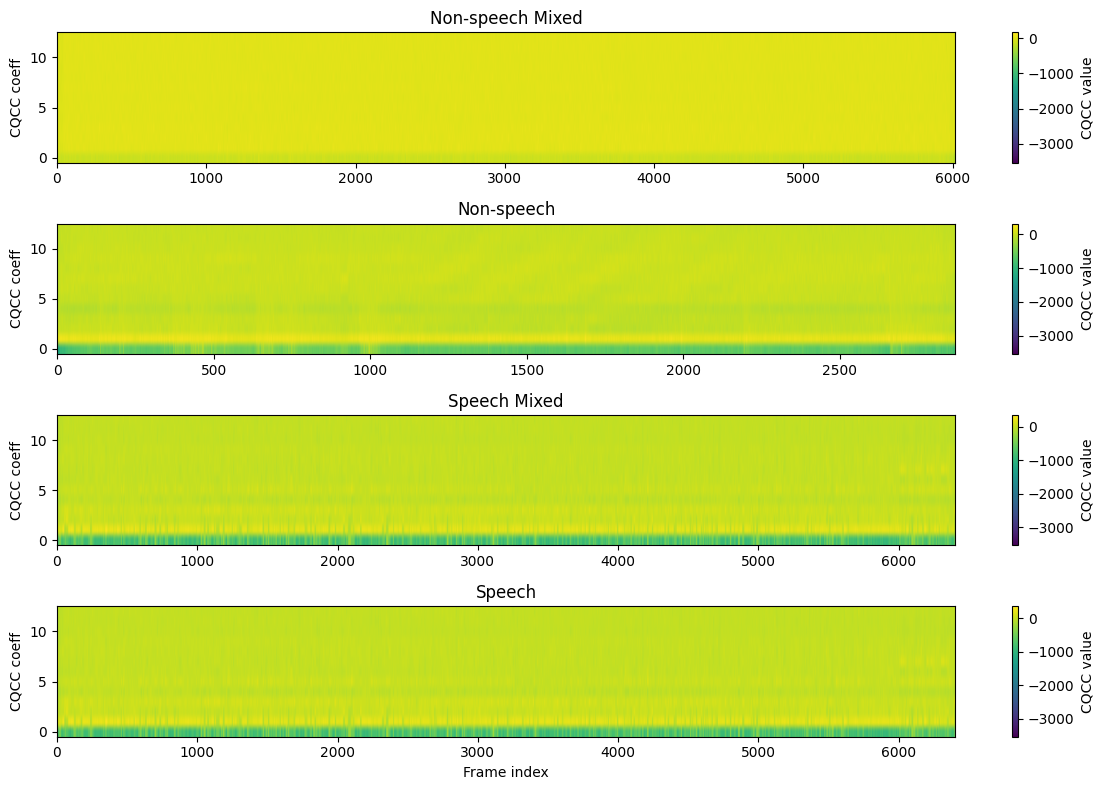

In [61]:
import matplotlib.pyplot as plt

mfcc_list = [n_sp_m_feature, n_sp_feature, sp_m_feature, sp_feature]
titles = ['Non-speech Mixed', 'Non-speech', 'Speech Mixed', 'Speech']

plt.figure(figsize=(12, 8))

for i, mfcc in enumerate(mfcc_list):
    plt.subplot(4, 1, i + 1)
    plt.imshow(mfcc.T, aspect='auto', origin='lower')
    plt.colorbar(label='CQCC value')
    plt.ylabel('CQCC coeff')
    plt.title(titles[i])

plt.xlabel('Frame index')
plt.tight_layout()
plt.show()
